# Sales Data Cleaning & Analysis with Python, Pandas & Matplotlib

**Auteur :** Zongo Fabrice Alex Darel
**Contexte :** Projet de portfolio #2 — Nettoyage + analyse de données de ventes.

## 🎯 Objectif
Nettoyer un dataset de ventes brutes, l'analyser et produire des visualisations
pour identifier les tendances métier (CA, top produits, régions).

## 📑 Sommaire
1. Imports & Configuration
2. Chargement du dataset
3. Inspection initiale
4. Data Quality Issues
5. Data Cleaning
6. Feature Engineering (calcul du CA)
7. Analyse exploratoire
8. Visualisations
9. Insights métier
10. Export & Conclusion

In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Pandas :", pd.__version__)
print("Matplotlib :", plt.matplotlib.__version__)
print("Seaborn :", sns.__version__)

Pandas : 2.3.3
Matplotlib : 3.10.6
Seaborn : 0.13.2


In [2]:
# ============================================================
# 2. CHARGEMENT
# ============================================================
df = pd.read_csv("data/raw/sales_raw.csv")
df_raw = df.copy()

print("Dimensions :", df.shape)
df.head(10)

Dimensions : (41, 8)


,order_id,order_date,customer_name,product,quantity,unit_price,region,payment_method
0,1001,2024-01-15,john smith,Laptop,2,850.0,Casablanca,Credit Card
1,1002,2024-01-20,Marie DUPONT,laptop,1,850.0,casablanca,credit card
2,1003,15/01/2024,paul martin,LAPTOP,3,850.0,CASABLANCA,CREDIT CARD
3,1004,2024-02-01,Sarah Johnson,Smartphone,1,450.0,Rabat,PayPal
4,1005,2024-02-10,NaN,smartphone,2,NaN,rabat,paypal
5,1006,2024-02-15,mohamed ali,Tablet,1,320.0,RABAT,PAYPAL
6,1007,2024/02/20,Emma Brown,tablet,4,320.0,Marrakech,Cash
7,1008,2024-03-01,Lucas Petit,TABLET,2,320.0,marrakech,cash
8,1009,2024-03-05,sophie leroy,Headphones,1,120.0,MARRAKECH,CASH
9,1010,2024-03-12,Ahmed BENANI,headphones,-1,120.0,Agadir,Bank Transfer


In [3]:
# ============================================================
# 3. INSPECTION INITIALE
# ============================================================
df.info()

print("\n--- Valeurs manquantes ---")
print(df.isnull().sum())

print("\n--- Doublons ---")
print("Doublons complets :", df.duplicated().sum())
print("Doublons sur order_id :", df["order_id"].duplicated().sum())

print("\n--- Statistiques ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        41 non-null     int64  
 1   order_date      41 non-null     object 
 2   customer_name   39 non-null     object 
 3   product         41 non-null     object 
 4   quantity        41 non-null     int64  
 5   unit_price      40 non-null     float64
 6   region          41 non-null     object 
 7   payment_method  41 non-null     object 
dtypes: float64(1), int64(2), object(5)
memory usage: 2.7+ KB

--- Valeurs manquantes ---
order_id          0
order_date        0
customer_name     2
product           0
quantity          0
unit_price        1
region            0
payment_method    0
dtype: int64

--- Doublons ---
Doublons complets : 1
Doublons sur order_id : 1

--- Statistiques ---


,order_id,quantity,unit_price
count,41.000000,41.000000,40.00000
mean,1020.731707,2.097561,184.25000
std,11.638351,1.374861,230.16591
min,1001.000000,-1.000000,-50.00000
25%,1011.000000,1.000000,35.00000
50%,1021.000000,2.000000,90.00000
75%,1030.000000,3.000000,215.00000
max,1040.000000,5.000000,850.00000


In [4]:
# Diagnostic des formats de dates
print("Formats de dates uniques :")
print(df["order_date"].str.len().value_counts())
print("\nExemples :")
print(df["order_date"].head(10).tolist())

Formats de dates uniques :
order_date
10    41
Name: count, dtype: int64

Exemples :
['2024-01-15', '2024-01-20', '15/01/2024', '2024-02-01', '2024-02-10', '2024-02-15', '2024/02/20', '2024-03-01', '2024-03-05', '2024-03-12']


In [5]:
# Diagnostic des produits
print("Produits uniques (brut) :", df["product"].nunique())
print(df["product"].value_counts().head(15))

Produits uniques (brut) : 39
product
Webcam         2
Charger        2
Laptop         1
Smartphone     1
smartphone     1
laptop         1
LAPTOP         1
  tablet       1
Tablet         1
TABLET         1
Headphones     1
Keyboard       1
  keyboard     1
headphones     1
HEADPHONES     1
Name: count, dtype: int64


In [6]:
# Diagnostic des régions
print("Régions uniques (brut) :", df["region"].nunique())
print(df["region"].value_counts())

Régions uniques (brut) : 22
region
Casablanca      3
Rabat           3
Fès             3
casablanca      2
rabat           2
CASABLANCA      2
RABAT           2
Marrakech       2
Agadir          2
MARRAKECH       2
AGADIR          2
agadir          2
fès             2
FES             2
TANGER          2
Tanger          2
  marrakech     1
  tanger        1
  rabat         1
marrakech       1
tanger          1
  casablanca    1
Name: count, dtype: int64


In [7]:
# Diagnostic quantités et prix
print("Quantités aberrantes (<= 0) :")
print(df[df["quantity"] <= 0][["order_id", "product", "quantity"]])

print("\nPrix aberrants (< 0) :")
print(df[df["unit_price"] < 0][["order_id", "product", "unit_price"]])

print("\nValeurs manquantes sur unit_price :")
print(df[df["unit_price"].isnull()][["order_id", "product", "unit_price"]])

Quantités aberrantes (<= 0) :
    order_id      product  quantity
9       1010  headphones         -1
22      1023      PRINTER         0

Prix aberrants (< 0) :
    order_id product  unit_price
15      1016  mouse        -50.0

Valeurs manquantes sur unit_price :
   order_id     product  unit_price
4      1005  smartphone         NaN


In [8]:
# ============================================================
# 4. NETTOYAGE
# ============================================================
# 4.1 Suppression des doublons
df = df.drop_duplicates().copy()
print("Après suppression doublons :", df.shape)

Après suppression doublons : (40, 8)


In [9]:
# 4.2 Standardisation des dates
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=False)

print("Type :", df["order_date"].dtype)
print("Plage :", df["order_date"].min(), "→", df["order_date"].max())

Type : datetime64[ns]
Plage : 2024-01-15 00:00:00 → 2024-12-30 00:00:00


In [10]:
# 4.3 Standardisation des colonnes texte
text_cols = ["customer_name", "product", "region", "payment_method"]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print(df[["customer_name", "product", "region", "payment_method"]].head(10))

   customer_name     product      region payment_method
0     John Smith      Laptop  Casablanca    Credit Card
1   Marie Dupont      Laptop  Casablanca    Credit Card
2    Paul Martin      Laptop  Casablanca    Credit Card
3  Sarah Johnson  Smartphone       Rabat         Paypal
4            NaN  Smartphone       Rabat         Paypal
5    Mohamed Ali      Tablet       Rabat         Paypal
6     Emma Brown      Tablet   Marrakech           Cash
7    Lucas Petit      Tablet   Marrakech           Cash
8   Sophie Leroy  Headphones   Marrakech           Cash
9   Ahmed Benani  Headphones      Agadir  Bank Transfer


In [30]:
# Corriger les accents manquants
df["region"] = df["region"].replace({"Fes": "Fès"})

# Vérification
print("Régions uniques après correction :", df["region"].nunique())
print(df["region"].value_counts())

Régions uniques après correction : 6
region
Casablanca    8
Rabat         8
Marrakech     6
Agadir        6
Fès           6
Tanger        6
Name: count, dtype: int64


In [31]:
# 4.4 Neutralisation des valeurs aberrantes
df.loc[df["quantity"] <= 0, "quantity"] = pd.NA
df.loc[df["unit_price"] <= 0, "unit_price"] = pd.NA

# Imputation par la médiane
median_qty = df["quantity"].median()
median_price = df["unit_price"].median()

df["quantity"] = df["quantity"].fillna(median_qty).astype(int)
df["unit_price"] = df["unit_price"].fillna(median_price)

print("Médiane quantity :", median_qty)
print("Médiane unit_price :", median_price)

Médiane quantity : 2.0
Médiane unit_price : 105.0


In [32]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
df["revenue"] = df["quantity"] * df["unit_price"]
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["year"] = df["order_date"].dt.year

print(df[["order_id", "order_date", "product", "quantity", "unit_price", "revenue", "month"]].head(10))

   order_id order_date     product  quantity  unit_price  revenue    month
0      1001 2024-01-15      Laptop         2       850.0   1700.0  2024-01
1      1002 2024-01-20      Laptop         1       850.0    850.0  2024-01
2      1003 2024-01-15      Laptop         3       850.0   2550.0  2024-01
3      1004 2024-02-01  Smartphone         1       450.0    450.0  2024-02
4      1005 2024-02-10  Smartphone         2       105.0    210.0  2024-02
5      1006 2024-02-15      Tablet         1       320.0    320.0  2024-02
6      1007 2024-02-20      Tablet         4       320.0   1280.0  2024-02
7      1008 2024-03-01      Tablet         2       320.0    640.0  2024-03
8      1009 2024-03-05  Headphones         1       120.0    120.0  2024-03
9      1010 2024-03-12  Headphones         2       120.0    240.0  2024-03


In [33]:
# ============================================================
# 6. ANALYSE EXPLORATOIRE
# ============================================================
total_revenue = df["revenue"].sum()
avg_order_value = df["revenue"].mean()
total_orders = len(df)
total_quantity = df["quantity"].sum()

print("=" * 50)
print("📊 KPIs GLOBAUX")
print("=" * 50)
print(f"CA total          : {total_revenue:,.2f} MAD")
print(f"Panier moyen      : {avg_order_value:,.2f} MAD")
print(f"Nombre de commandes : {total_orders}")
print(f"Quantité totale vendue : {total_quantity}")

📊 KPIs GLOBAUX
CA total          : 15,650.00 MAD
Panier moyen      : 391.25 MAD
Nombre de commandes : 40
Quantité totale vendue : 86


In [34]:
# Top 10 produits par CA
top_products = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

product
Laptop        5100.0
Camera        2800.0
Tablet        2240.0
Monitor       1260.0
Printer        900.0
Smartphone     660.0
Headphones     600.0
Keyboard       600.0
Speaker        540.0
Charger        315.0
Name: revenue, dtype: float64


In [35]:
# CA par région
revenue_by_region = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_region)

region
Casablanca    5760.0
Marrakech     4840.0
Rabat         2060.0
Agadir        1395.0
Tanger         980.0
Fès            615.0
Name: revenue, dtype: float64


In [36]:
# CA par mois
revenue_by_month = (
    df.groupby("month")["revenue"]
    .sum()
    .sort_index()
)
print(revenue_by_month)

month
2024-01    5100.0
2024-02    2260.0
2024-03    1240.0
2024-04     600.0
2024-05     230.0
2024-06    1260.0
2024-07     900.0
2024-08    2800.0
2024-09     540.0
2024-10     210.0
2024-11     150.0
2024-12     360.0
Name: revenue, dtype: float64


In [37]:
# CA par méthode de paiement
revenue_by_payment = (
    df.groupby("payment_method")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("=" * 50)
print("💳 CA PAR MÉTHODE DE PAIEMENT")
print("=" * 50)
print(revenue_by_payment)

# Répartition en %
print("\nRépartition (%) :")
print((revenue_by_payment / revenue_by_payment.sum() * 100).round(1))

💳 CA PAR MÉTHODE DE PAIEMENT
payment_method
Credit Card      8270.0
Cash             3200.0
Paypal           2360.0
Bank Transfer    1820.0
Name: revenue, dtype: float64

Répartition (%) :
payment_method
Credit Card      52.8
Cash             20.4
Paypal           15.1
Bank Transfer    11.6
Name: revenue, dtype: float64


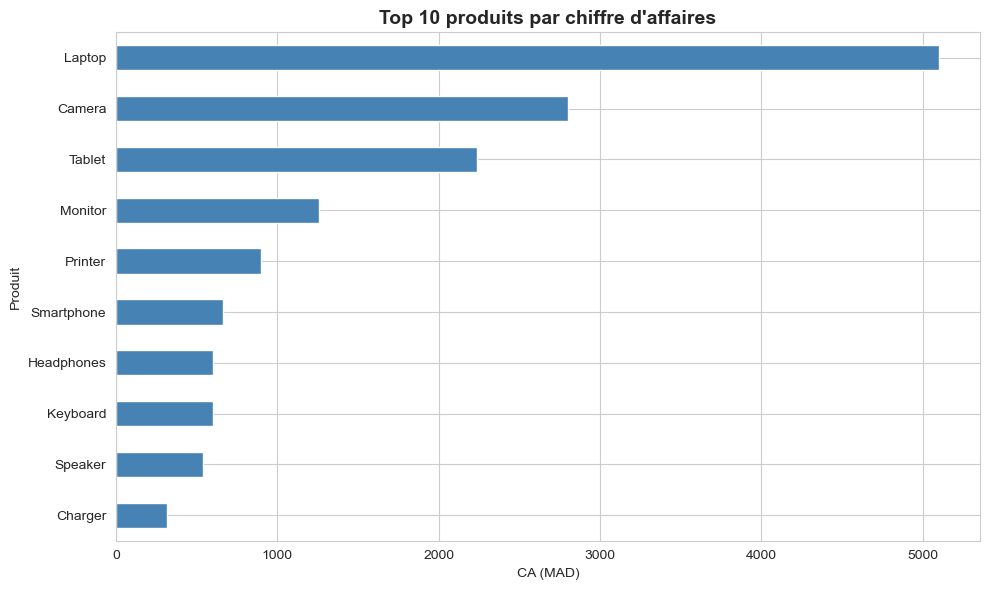

In [38]:
# ============================================================
# 7. VISUALISATIONS
# ============================================================
plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="steelblue")
plt.title("Top 10 produits par chiffre d'affaires", fontsize=14, fontweight="bold")
plt.xlabel("CA (MAD)")
plt.ylabel("Produit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/charts/top_products.png", dpi=100)
plt.show()

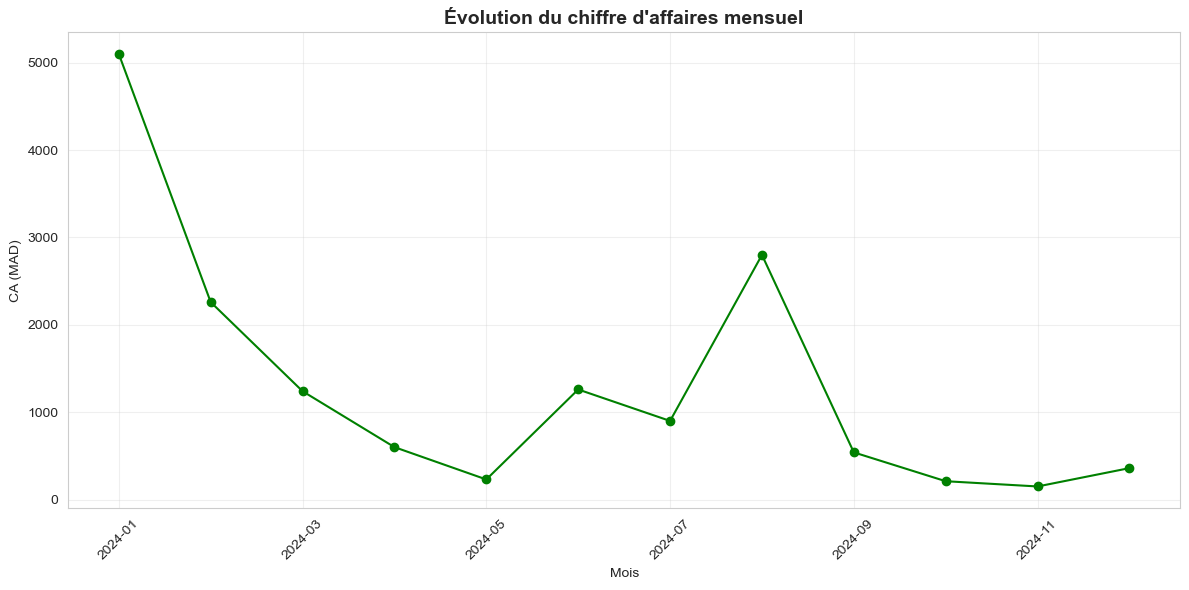

In [39]:
plt.figure(figsize=(12, 6))
revenue_by_month.plot(kind="line", marker="o", color="green")
plt.title("Évolution du chiffre d'affaires mensuel", fontsize=14, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("CA (MAD)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/charts/revenue_by_month.png", dpi=100)
plt.show()

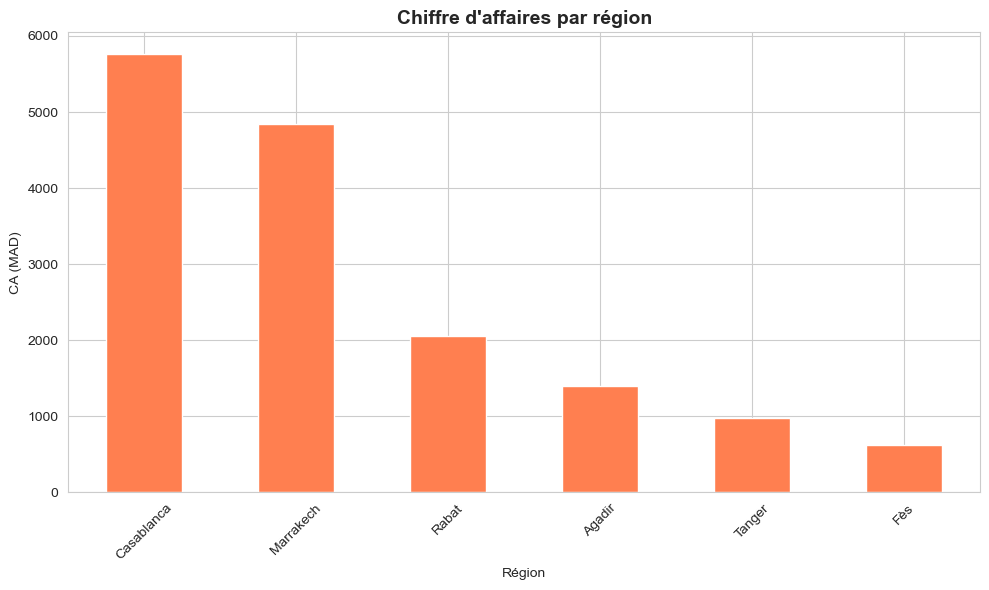

In [40]:
plt.figure(figsize=(10, 6))
revenue_by_region.plot(kind="bar", color="coral")
plt.title("Chiffre d'affaires par région", fontsize=14, fontweight="bold")
plt.xlabel("Région")
plt.ylabel("CA (MAD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/revenue_by_region.png", dpi=100)
plt.show()

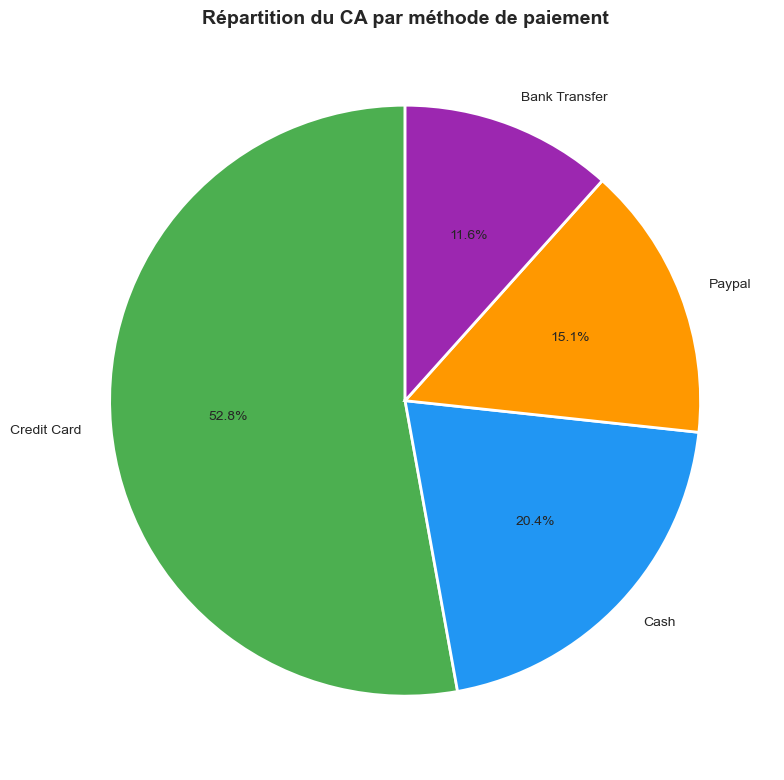

In [41]:
plt.figure(figsize=(8, 8))
colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"]
revenue_by_payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Répartition du CA par méthode de paiement", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.savefig("outputs/charts/revenue_by_payment.png", dpi=100)
plt.show()

In [42]:
# ============================================================
# 8. EXPORT
# ============================================================
df.to_csv("data/cleaned/sales_cleaned.csv", index=False)
print("✅ Dataset nettoyé exporté :", df.shape)

✅ Dataset nettoyé exporté : (40, 11)


In [43]:
# Vérification
df_check = pd.read_csv("data/cleaned/sales_cleaned.csv")
print("\nAperçu du fichier exporté :")
df_check.head()


Aperçu du fichier exporté :


,order_id,order_date,customer_name,product,quantity,unit_price,region,payment_method,revenue,month,year
0,1001,2024-01-15,John Smith,Laptop,2,850.0,Casablanca,Credit Card,1700.0,2024-01,2024
1,1002,2024-01-20,Marie Dupont,Laptop,1,850.0,Casablanca,Credit Card,850.0,2024-01,2024
2,1003,2024-01-15,Paul Martin,Laptop,3,850.0,Casablanca,Credit Card,2550.0,2024-01,2024
3,1004,2024-02-01,Sarah Johnson,Smartphone,1,450.0,Rabat,Paypal,450.0,2024-02,2024
4,1005,2024-02-10,NaN,Smartphone,2,105.0,Rabat,Paypal,210.0,2024-02,2024


## 📈 Insights métier

### 🏆 Concentration des ventes
- **Laptop** est le produit phare : **32.6 % du CA total** (5 100 MAD).
- Les 3 premiers produits (Laptop, Camera, Tablet) représentent **64.8 % du CA**.
- ⚠️ Risque de dépendance : une baisse des ventes de Laptop impacterait fortement le CA global.

### 🗺️ Concentration géographique
- **Casablanca + Marrakech = 67.7 % du CA**.
- Le marché est très concentré sur 2 villes.
- Opportunité : développer Agadir, Tanger et Fès (marchés sous-exploités).

### 📅 Saisonnalité marquée
- **Janvier** : pic à 5 100 MAD (probablement promotions + ventes Laptop).
- **Août** : second pic à 2 800 MAD (achats Camera, saison touristique).
- **Novembre** : creux à 150 MAD.
- Recommandation : anticiper les stocks pour Janvier et Août.

### 💳 Préférence de paiement
- **Credit Card domine (52.8 %)** : clientèle digitalisée.
- **Cash = 20.4 %** : encore une part significative, surtout en boutique.
- Recommandation : sécuriser le paiement en ligne et proposer des facilités.

### 🎯 Recommandations stratégiques
1. **Fidéliser** sur le Laptop (produit phare) → offres premium.
2. **Développer** les régions Agadir, Tanger, Fès (fort potentiel).
3. **Anticiper** les stocks pour Janvier et Août.
4. **Renforcer** le paiement par Credit Card (promos, cashback).